In [101]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
import joblib



In [102]:
df = pd.read_csv("/content/financial_behavior_ai_training_dataset_3000.csv")

In [103]:
df.head()
print("Rows and Columns:", df.shape)
df.info()
df.isnull().sum()


Rows and Columns: (3000, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             3000 non-null   object 
 1   User_ID                    3000 non-null   object 
 2   Age                        3000 non-null   int64  
 3   Gender                     3000 non-null   object 
 4   Monthly_Allowance          3000 non-null   int64  
 5   Parent_Budget_Level        3000 non-null   object 
 6   Financial_Profile          3000 non-null   object 
 7   Transaction_Date           3000 non-null   object 
 8   Day_of_Week                3000 non-null   object 
 9   Month                      3000 non-null   object 
 10  Time_of_Day                3000 non-null   object 
 11  Merchant_Category          3000 non-null   object 
 12  Amount                     3000 non-null   float64
 13  Payment_Method     

,0
Transaction_ID,0
User_ID,0
Age,0
Gender,0
Monthly_Allowance,0
Parent_Budget_Level,0
Financial_Profile,0
Transaction_Date,0
Day_of_Week,0
Month,0


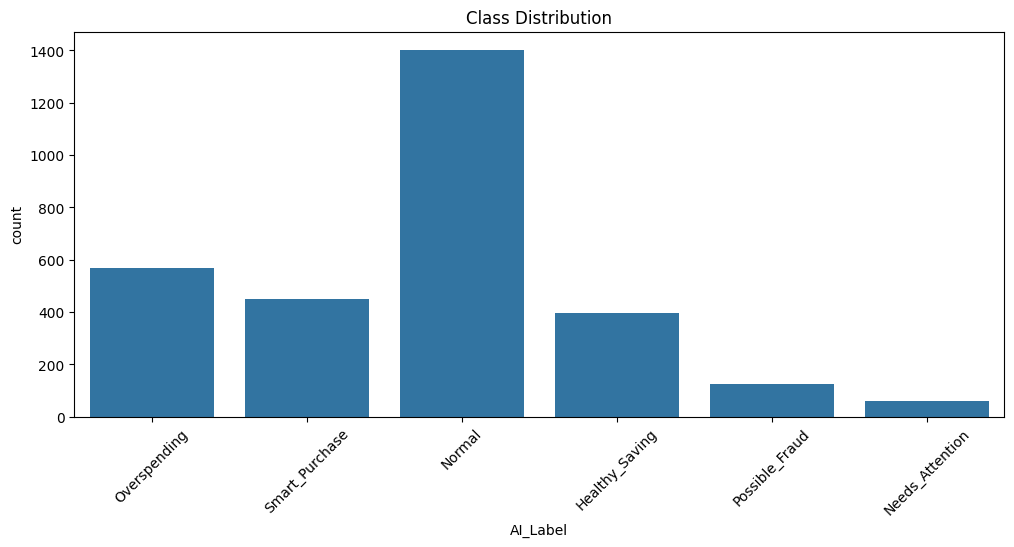

In [104]:
df["AI_Label"].value_counts()

plt.figure(figsize=(12,5))
sns.countplot(x=df["AI_Label"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


In [105]:
X = df.drop("AI_Label", axis=1)
y = df["AI_Label"]

In [106]:
X = pd.get_dummies(X, drop_first=True)

In [107]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [109]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 3422)
X_test shape: (600, 3422)
y_train shape: (2400,)
y_test shape: (600,)


In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3 style="color:PINK;">
    " Logistic Regression "
</h3>

In [111]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [112]:
y_pred_log = log_model.predict(X_test_scaled)

In [113]:
log_accuracy = accuracy_score(y_test, y_pred_log)

log_precision = precision_score(y_test, y_pred_log, average="weighted")

log_recall = recall_score(y_test, y_pred_log, average="weighted")

log_f1 = f1_score(y_test, y_pred_log, average="weighted")

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)

Accuracy: 0.99
Precision: 0.9901461988304093
Recall: 0.99
F1-score: 0.988940381928272


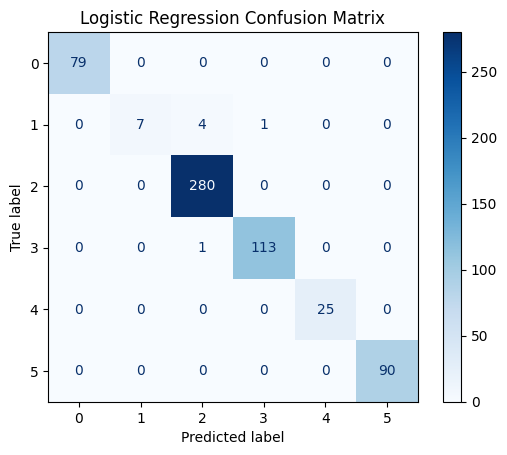

In [114]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()



<h3 style="color:PINK;">
    " Random Forest "
</h3>

In [115]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [116]:
y_pred_rf = rf_model.predict(X_test)

In [117]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf, average="weighted")

rf_recall = recall_score(y_test, y_pred_rf, average="weighted")

rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Accuracy: 0.9916666666666667
Precision: 0.991812865497076
Recall: 0.9916666666666667
F1-score: 0.9913316477033292


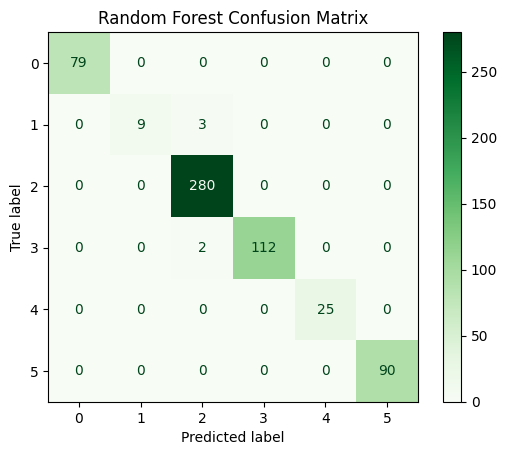

In [118]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()




<h3 style="color:PINK;">
    "K-Nearest Neighbors (KNN)
"
</h3>

In [119]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [120]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [121]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(y_test, y_pred_knn, average="weighted")

knn_recall = recall_score(y_test, y_pred_knn, average="weighted")

knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

Accuracy: 0.6583333333333333
Precision: 0.6691276007288662
Recall: 0.6583333333333333
F1-score: 0.6291513024890634


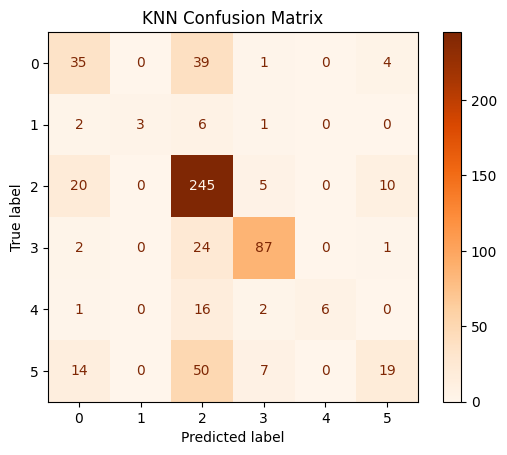

In [122]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

disp.plot(cmap="Oranges")

plt.title("KNN Confusion Matrix")

plt.show()




<h3 style="color:PINK;">
    "DecisionTree"
</h3>





Accuracy: 0.9916666666666667
Precision: 0.9914071146245059
Recall: 0.9916666666666667
F1-score: 0.9915037022973229


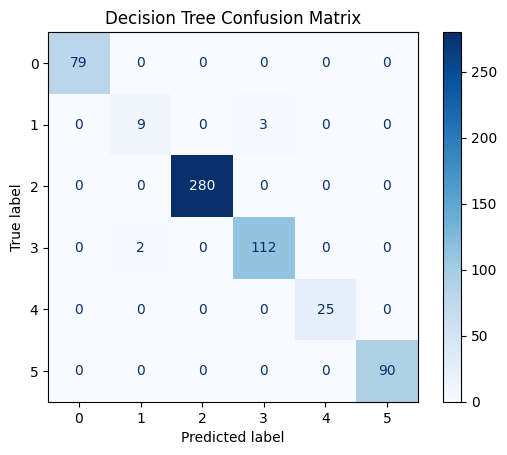

In [123]:


dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()




<h3 style="color:PINK;">
    "catboost"
</h3>





In [124]:
pip install catboost

Accuracy: 0.9966666666666667
Precision: 0.997142857142857
Recall: 0.9966666666666667
F1-score: 0.996780122532335


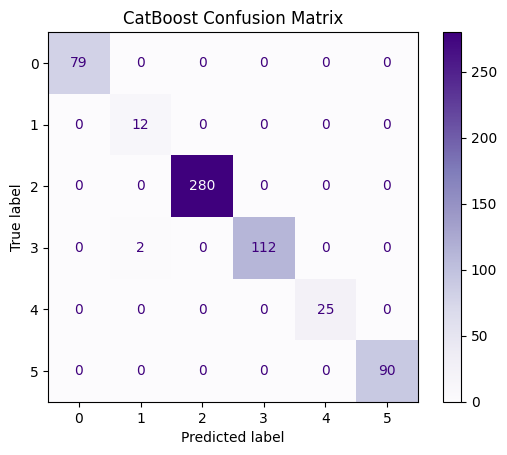

In [125]:


cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

cat_accuracy = accuracy_score(y_test, y_pred_cat)
cat_precision = precision_score(y_test, y_pred_cat, average="weighted")
cat_recall = recall_score(y_test, y_pred_cat, average="weighted")
cat_f1 = f1_score(y_test, y_pred_cat, average="weighted")

print("Accuracy:", cat_accuracy)
print("Precision:", cat_precision)
print("Recall:", cat_recall)
print("F1-score:", cat_f1)

cm_cat = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cat)

disp.plot(cmap="Purples")

plt.title("CatBoost Confusion Matrix")

plt.show()

<h3 style="color:PINK;">
 > Summary Table
    "Model Comparison "
</h3>

In [132]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN",
        "Decision Tree",
        "CatBoost"],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        knn_accuracy,
        dt_accuracy,
        cat_accuracy],

    "Precision": [
        log_precision,
        rf_precision,
        knn_precision,
        dt_precision,
        cat_precision],

    "Recall": [
        log_recall,
        rf_recall,
        knn_recall,
        dt_recall,
        cat_recall],

    "F1-Score": [
        log_f1,
        rf_f1,
        knn_f1,
        dt_f1,
        cat_f1]})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.990000,0.990146,0.990000,0.988940
1,Random Forest,0.991667,0.991813,0.991667,0.991332
2,KNN,0.658333,0.669128,0.658333,0.629151
3,Decision Tree,0.991667,0.991407,0.991667,0.991504
4,CatBoost,0.996667,0.997143,0.996667,0.996780


In [127]:

joblib.dump(cat_model, "catboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [128]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print(feature_names)

['Age', 'Monthly_Allowance', 'Amount', 'Is_Weekend', 'Previous_Savings', 'Current_Savings', 'Saving_Rate', 'Spending_Ratio', 'Avg_Last_7_Transactions', 'Avg_Last_30_Days', 'Spending_Trend', 'Consecutive_Spending_Days', 'Cafe_Spending_Ratio', 'Education_Spending_Ratio', 'Entertainment_Ratio', 'Weekend_Spending_Ratio', 'Transaction_Frequency', 'Device_Changed', 'Location_Changed', 'High_Amount_Flag', 'Night_Transaction', 'Rapid_Transactions', 'Fraud_Risk_Score', 'Transaction_ID_TX00002', 'Transaction_ID_TX00003', 'Transaction_ID_TX00004', 'Transaction_ID_TX00005', 'Transaction_ID_TX00006', 'Transaction_ID_TX00007', 'Transaction_ID_TX00008', 'Transaction_ID_TX00009', 'Transaction_ID_TX00010', 'Transaction_ID_TX00011', 'Transaction_ID_TX00012', 'Transaction_ID_TX00013', 'Transaction_ID_TX00014', 'Transaction_ID_TX00015', 'Transaction_ID_TX00016', 'Transaction_ID_TX00017', 'Transaction_ID_TX00018', 'Transaction_ID_TX00019', 'Transaction_ID_TX00020', 'Transaction_ID_TX00021', 'Transaction_ID

In [129]:
loaded_model = joblib.load("catboost_model.pkl")

In [130]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print(prediction)

[[2]]
